# Experiment 03 — Predicting hidden embeddings

**Question:** Can a model learn to predict the representation of a hidden image region without reconstructing its pixels?

In Experiment 02, the model was rewarded for guessing every RGB value in the hidden patches. Here, an online model predicts the target encoder’s vectors for those same patches. The target encoder is a slowly updated copy of the online encoder.

This is a small teaching version of JEPA. It keeps the image, patch grid, central mask, and training subset from Experiment 02 so we can focus on the changed target.


## Our prediction

The embedding prediction loss should fall as the predictor and online encoder learn to match the target encoder on hidden patches. The prediction is not an RGB image, so there is no pixel reconstruction to inspect. We will compare vectors directly and track their cosine similarity.


## What changes from Experiment 02?

The model still receives images with a central block hidden. The target encoder sees the complete image, but its outputs are stopped from carrying gradients. The online context encoder sees mask tokens in place of hidden patches. A predictor uses the encoded context to predict target vectors, and the loss compares only the hidden positions.

Both encoder and predictor receive gradients. The target encoder receives no gradients; after each optimizer step, its weights move a small amount toward the online encoder weights (an exponential moving average, or EMA).


In [1]:
from pathlib import Path
import copy
import sys

search_locations = (Path.cwd(), *Path.cwd().parents)
project_root = next(
    (path for path in search_locations if (path / 'pyproject.toml').exists()),
    None,
)
if project_root is None:
    raise RuntimeError('Could not find the JEPA Experiments project root')
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print('Project root:', project_root)


Project root: /Users/houstonmuzamhindo/Desktop/Startups/Books/JEPA Experiments


In [2]:
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch import nn
from torch.optim import AdamW
from torch.utils.data import DataLoader, Subset

from jepa.data import load_cifar10
from jepa.device import best_device
from jepa.masking import centered_block_mask
from jepa.patches import patchify

torch.manual_seed(7)
device = best_device()
device


device(type='mps')

## 1. Fix the experimental configuration

We use the same 10,000-image training subset and central 4 × 4 patch mask as Experiment 02. The model never receives CIFAR-10 labels. As in Experiment 02, this notebook trains on and displays examples from the same subset, so its outputs measure training fit rather than performance on unseen images.


In [3]:
IMAGE_SIZE = 32
PATCH_SIZE = 4
GRID_SIZE = IMAGE_SIZE // PATCH_SIZE
PATCH_VALUES = 3 * PATCH_SIZE * PATCH_SIZE
EMBEDDING_DIM = 128
BATCH_SIZE = 64
TRAINING_IMAGES = 10_000
EPOCHS = 10
LEARNING_RATE = 3e-4
EMA_DECAY = 0.99

mask = centered_block_mask(GRID_SIZE, block_size=4, device=device)
print(f'Patches: {GRID_SIZE} × {GRID_SIZE} = {GRID_SIZE ** 2}')
print(f'Hidden patches: {int(mask.sum())} ({mask.float().mean().item():.0%})')


Patches: 8 × 8 = 64
Hidden patches: 16 (25%)


In [4]:
dataset = load_cifar10(train=True)
training_data = Subset(dataset, range(TRAINING_IMAGES))
loader = DataLoader(training_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
images, _ = next(iter(loader))
print('Batch shape:', tuple(images.shape))


Batch shape: (64, 3, 32, 32)


## 2. Define the encoders and predictor

The encoder turns each 4 × 4 RGB patch into a 128-number token and adds a learned position vector. In the online encoder, hidden patches are replaced with a learned mask token before the transformer. The target encoder uses the same architecture, initialized from the online encoder and then updated by EMA.

The predictor reads the online encoder’s tokens and estimates one target vector per patch. It is trained only at the masked positions. The target is normalized before comparison so the loss focuses on the direction of each representation rather than its scale.


In [5]:
class PatchEncoder(nn.Module):
    def __init__(self, *, image_size=32, patch_size=4, embedding_dim=128, depth=4, heads=4):
        super().__init__()
        self.patch_size = patch_size
        self.number_of_patches = (image_size // patch_size) ** 2
        patch_values = 3 * patch_size * patch_size
        self.patch_projection = nn.Linear(patch_values, embedding_dim)
        self.position_embedding = nn.Parameter(torch.zeros(1, self.number_of_patches, embedding_dim))
        self.mask_token = nn.Parameter(torch.zeros(1, 1, embedding_dim))
        layer = nn.TransformerEncoderLayer(
            d_model=embedding_dim,
            nhead=heads,
            dim_feedforward=embedding_dim * 4,
            dropout=0.1,
            activation='gelu',
            batch_first=True,
            norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(
            layer, num_layers=depth, norm=nn.LayerNorm(embedding_dim)
        )
        nn.init.normal_(self.position_embedding, std=0.02)
        nn.init.normal_(self.mask_token, std=0.02)

    def forward(self, images, mask=None):
        patches = patchify(images, self.patch_size)
        tokens = self.patch_projection(patches)
        if mask is not None:
            tokens = torch.where(mask.reshape(1, -1, 1), self.mask_token, tokens)
        return self.transformer(tokens + self.position_embedding)


class PatchPredictor(nn.Module):
    def __init__(self, *, embedding_dim=128, depth=2, heads=4, number_of_patches=64):
        super().__init__()
        self.position_embedding = nn.Parameter(torch.zeros(1, number_of_patches, embedding_dim))
        layer = nn.TransformerEncoderLayer(
            d_model=embedding_dim,
            nhead=heads,
            dim_feedforward=embedding_dim * 4,
            dropout=0.1,
            activation='gelu',
            batch_first=True,
            norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(
            layer, num_layers=depth, norm=nn.LayerNorm(embedding_dim)
        )
        self.output_projection = nn.Linear(embedding_dim, embedding_dim)
        nn.init.normal_(self.position_embedding, std=0.02)

    def forward(self, context_tokens):
        return self.output_projection(self.transformer(context_tokens + self.position_embedding))


## 3. Create the online and target networks

The target starts as an exact copy of the online encoder. We freeze its parameters and keep it in evaluation mode. The predictor and online encoder are optimized together; after each update, EMA keeps the target moving more smoothly than copying the latest online weights directly.


In [6]:
context_encoder = PatchEncoder(embedding_dim=EMBEDDING_DIM).to(device)
target_encoder = copy.deepcopy(context_encoder).to(device)
target_encoder.requires_grad_(False)
target_encoder.eval()
predictor = PatchPredictor(embedding_dim=EMBEDDING_DIM).to(device)

trainable_parameters = list(context_encoder.parameters()) + list(predictor.parameters())
optimizer = AdamW(trainable_parameters, lr=LEARNING_RATE, weight_decay=0.05)
parameter_count = sum(parameter.numel() for parameter in trainable_parameters)
print(f'Trainable parameters: {parameter_count:,}')


/var/folders/g6/tzm4yfv92sdfs2hzr3bfyzph0000gn/T/ipykernel_31914/4237554304.py:19: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(
/var/folders/g6/tzm4yfv92sdfs2hzr3bfyzph0000gn/T/ipykernel_31914/4237554304.py:46: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


Trainable parameters: 1,229,440


## Architecture and gradient flow

```text
complete image ──> target encoder (EMA, no gradients) ──> target patch vectors
                                                            │
masked image ──> online context encoder ──> predictor ──────┴─> hidden-patch loss
                        ↑ gradients              ↑ gradients
```

The hidden locations are the same in the context and target sequences. Only the context image has its central patch pixels replaced by learned mask tokens.


## 4. Check the tensor shapes and initial loss

For one batch, both encoders produce 64 vectors of length 128. The predictor also produces 64 vectors. We will use only the 16 central predictions when calculating loss.


In [7]:
example_batch = images[:2].to(device)
with torch.no_grad():
    target_tokens = target_encoder(example_batch)
context_tokens = context_encoder(example_batch, mask)
predicted_tokens = predictor(context_tokens)

print('Target tokens:   ', tuple(target_tokens.shape))
print('Context tokens:  ', tuple(context_tokens.shape))
print('Predicted tokens:', tuple(predicted_tokens.shape))


Target tokens:    (2, 64, 128)
Context tokens:   (2, 64, 128)
Predicted tokens: (2, 64, 128)


In [8]:
def embedding_prediction_loss(predicted, target, mask):
    predicted = F.normalize(predicted[:, mask], dim=-1)
    target = F.normalize(target[:, mask], dim=-1)
    return F.mse_loss(predicted, target)

initial_loss = embedding_prediction_loss(predicted_tokens, target_tokens, mask)
initial_similarity = F.cosine_similarity(
    predicted_tokens[:, mask], target_tokens[:, mask], dim=-1
).mean()
print(f'Initial hidden-patch loss: {initial_loss.item():.6f}')
print(f'Initial cosine similarity: {initial_similarity.item():.4f}')


Initial hidden-patch loss: 0.014584
Initial cosine similarity: 0.0666


## 5. Train with an EMA target encoder

For each batch, the target encoder embeds the full image without gradients. The context encoder sees the hidden patches replaced by mask tokens. We update the context encoder and predictor from the hidden-position loss, then update the target encoder with an EMA step.


In [9]:
def update_target_encoder(online, target, decay):
    with torch.no_grad():
        for online_parameter, target_parameter in zip(online.parameters(), target.parameters()):
            target_parameter.lerp_(online_parameter, 1.0 - decay)

losses = []
similarities = []

for epoch in range(EPOCHS):
    context_encoder.train()
    predictor.train()
    total_loss = 0.0
    total_similarity = 0.0
    examples_seen = 0

    for batch, _ in loader:
        batch = batch.to(device)
        with torch.no_grad():
            target = target_encoder(batch)
        context = context_encoder(batch, mask)
        predicted = predictor(context)
        loss = embedding_prediction_loss(predicted, target, mask)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        update_target_encoder(context_encoder, target_encoder, EMA_DECAY)

        count = batch.shape[0]
        total_loss += loss.item() * count
        total_similarity += F.cosine_similarity(
            predicted[:, mask].detach(), target[:, mask], dim=-1
        ).mean().item() * count
        examples_seen += count

    epoch_loss = total_loss / examples_seen
    epoch_similarity = total_similarity / examples_seen
    losses.append(epoch_loss)
    similarities.append(epoch_similarity)
    print(
        f'Epoch {epoch + 1:02d}/{EPOCHS}: '
        f'loss={epoch_loss:.6f}, hidden cosine similarity={epoch_similarity:.4f}'
    )


Epoch 01/10: loss=0.000605, hidden cosine similarity=0.9613
Epoch 02/10: loss=0.000094, hidden cosine similarity=0.9940
Epoch 03/10: loss=0.000090, hidden cosine similarity=0.9942
Epoch 04/10: loss=0.000110, hidden cosine similarity=0.9929
Epoch 05/10: loss=0.000161, hidden cosine similarity=0.9897
Epoch 06/10: loss=0.000228, hidden cosine similarity=0.9854
Epoch 07/10: loss=0.000305, hidden cosine similarity=0.9805
Epoch 08/10: loss=0.000325, hidden cosine similarity=0.9792
Epoch 09/10: loss=0.000351, hidden cosine similarity=0.9775
Epoch 10/10: loss=0.000355, hidden cosine similarity=0.9773


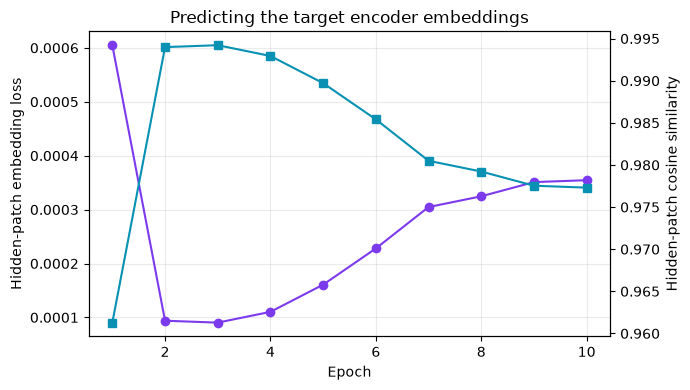

In [10]:
figure, loss_axis = plt.subplots(figsize=(7, 4))
loss_axis.plot(range(1, EPOCHS + 1), losses, marker='o', color='#7c3aed', label='Normalized MSE')
loss_axis.set_xlabel('Epoch')
loss_axis.set_ylabel('Hidden-patch embedding loss')
loss_axis.grid(alpha=0.25)
similarity_axis = loss_axis.twinx()
similarity_axis.plot(range(1, EPOCHS + 1), similarities, marker='s', color='#0891b2', label='Cosine similarity')
similarity_axis.set_ylabel('Hidden-patch cosine similarity')
loss_axis.set_title('Predicting the target encoder embeddings')
figure.tight_layout();


## 6. Compare predicted and target embeddings

These examples are from the first training batch. Each row in the heatmaps is one of the 16 hidden patches; each column is one of the 128 embedding dimensions. Similar patterns indicate that the predictor has matched the target representation. The dimensions are learned features, so an individual column does not correspond to a named colour or object part.


/var/folders/g6/tzm4yfv92sdfs2hzr3bfyzph0000gn/T/ipykernel_31914/2004105992.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  figure.tight_layout();


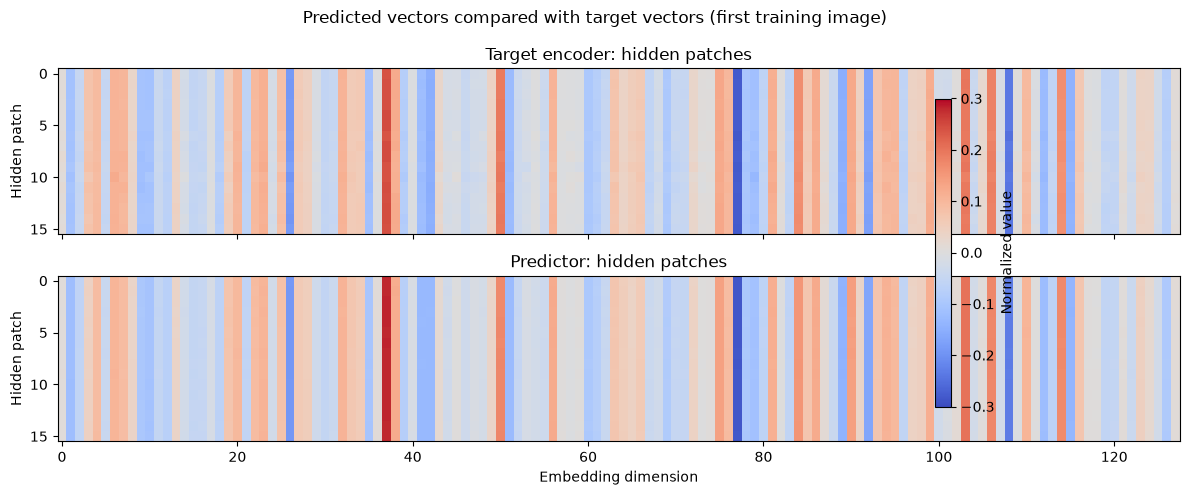

In [11]:
context_encoder.eval()
predictor.eval()
examples = images[:6].to(device)
with torch.no_grad():
    target = target_encoder(examples)
    predicted = predictor(context_encoder(examples, mask))

predicted_hidden = F.normalize(predicted[:, mask], dim=-1).cpu()
target_hidden = F.normalize(target[:, mask], dim=-1).cpu()
figure, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
for axis, values, title in zip(
    axes,
    (target_hidden[0], predicted_hidden[0]),
    ('Target encoder: hidden patches', 'Predictor: hidden patches'),
):
    axis.imshow(values, aspect='auto', cmap='coolwarm', vmin=-0.3, vmax=0.3)
    axis.set_ylabel('Hidden patch')
    axis.set_title(title)
axes[-1].set_xlabel('Embedding dimension')
figure.colorbar(axes[0].images[0], ax=axes, label='Normalized value', shrink=0.8)
figure.suptitle('Predicted vectors compared with target vectors (first training image)')
figure.tight_layout();


In [12]:
per_patch_similarity = F.cosine_similarity(predicted_hidden, target_hidden, dim=-1)[0]
print('Cosine similarity for the 16 hidden patches:')
print(per_patch_similarity.reshape(4, 4).numpy().round(3))


Cosine similarity for the 16 hidden patches:
[[0.994 0.994 0.994 0.993]
 [0.994 0.994 0.992 0.994]
 [0.992 0.99  0.992 0.991]
 [0.994 0.994 0.994 0.994]]


## 7. Check that the target embeddings have not collapsed

Prediction agreement is only useful if the target vectors still vary with the image and patch. If every target becomes almost the same vector, the predictor can achieve high cosine similarity without learning useful visual structure. The next measurements examine variation across features, patches, and images.

In [ ]:
with torch.no_grad():
    evaluation_tokens = F.normalize(target_encoder(images.to(device)), dim=-1).cpu()

flat_tokens = evaluation_tokens.reshape(-1, EMBEDDING_DIM)
mean_feature_std = flat_tokens.std(dim=0).mean()
image_vectors = F.normalize(evaluation_tokens.mean(dim=1), dim=-1)
across_image_similarity = F.cosine_similarity(
    image_vectors, torch.roll(image_vectors, shifts=1, dims=0), dim=-1
).mean()
image_centres = F.normalize(evaluation_tokens.mean(dim=1, keepdim=True), dim=-1)
within_image_patch_similarity = F.cosine_similarity(
    evaluation_tokens, image_centres, dim=-1
).mean()

centred = flat_tokens - flat_tokens.mean(dim=0, keepdim=True)
singular_values = torch.linalg.svdvals(centred)
weights = singular_values / singular_values.sum()
effective_rank = torch.exp(-(weights * torch.log(weights + 1e-12)).sum())

print(f'Mean feature standard deviation: {mean_feature_std.item():.6f}')
print(f'Within-image patch similarity:   {within_image_patch_similarity.item():.4f}')
print(f'Across-image similarity:         {across_image_similarity.item():.4f}')
print(f'Effective representation rank:   {effective_rank.item():.2f} / {EMBEDDING_DIM}')

## What happened in this run

Before training, the hidden-patch loss was `0.014584` and cosine similarity was `0.0666`. By epoch 3, loss had fallen to its minimum of `0.000090` and similarity had reached its maximum of `0.9942`. The curve then reversed direction. At epoch 10, loss had risen to `0.000355` and similarity had fallen to `0.9773`. Training therefore improved prediction dramatically, but it did not improve steadily for all ten epochs.

For the displayed training image, the 16 predicted patches had cosine similarities between `0.990` and `0.994` with their targets. The two heatmaps match closely. However, the rows inside the target heatmap also look almost identical to one another. That is a warning: the representation may be becoming too similar across different patches.

Run the diversity cell above while the trained models are still in memory. A healthy representation should retain variation across patches and images. Very high within-image and across-image similarity, very small feature standard deviation, or very low effective rank would be evidence of representation collapse.

## What this experiment does not prove

The high predictor–target similarity does not by itself show that the representation contains useful information. Both networks could agree because the target vectors are informative, or because many inputs have been mapped to nearly the same vector. The loss also uses the training subset, so it does not measure transfer to unseen images.

## What we learned

The model learned to match an EMA encoder’s hidden-patch vectors without reconstructing pixels. That confirms the basic training mechanism. The run also taught us that prediction agreement is not enough: we must measure whether the representation remains diverse and whether it carries useful information. The new diversity check addresses the first question; the later linear-probe experiment will address the second.
